In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [324]:
rng = np.random.default_rng(2)
x_train = rng.normal(0.4, 0.2, 13)
y_train = rng.normal(0.5, 0.15, 13)

rng2 = np.random.default_rng(1)
additional_x_train = rng2.normal(0.4, 0.1, 25)
additional_y_train = rng2.normal(0.3, 0.17, 25)

In [345]:
train = np.column_stack((x_train, y_train))
train  = np.delete(train, (3), axis=0)

additional_train = np.column_stack((additional_x_train, additional_y_train))[:-1]

In [346]:

x_test = [0.6, 0.5, 0.2]
y_test = [0.1, 0.4, 0.8]

test = np.column_stack((x_test, y_test))
test

array([[0.6, 0.1],
       [0.5, 0.4],
       [0.2, 0.8]])

In [347]:
train.shape, additional_train.shape

((12, 2), (24, 2))

In [348]:
from scipy.spatial import KDTree

tree = KDTree(train_together := np.concat((train, additional_train)))
distances, indices = tree.query(test, k=3)

nn_train = train_together[indices]
nn_train.shape

(3, 3, 2)

In [349]:
from scipy.spatial import ConvexHull

hull = ConvexHull(train)

In [350]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
from scipy.interpolate import splprep, splev



In [373]:
def get_smooth(train, x_inflation, y_inflation, xskew):
    # Compute convex hull
    hull = ConvexHull(train)
    hull_points = train[hull.vertices]

    # Optional: close the loop
    hull_points = np.vstack([hull_points, hull_points[0]])

    # Spline interpolation (smooth the polygon)
    tck, u = splprep([hull_points[:,0], hull_points[:,1]], s=0.01, per=True)  # s controls smoothness
    u_new = np.linspace(0, 1, 300)
    x_smooth, y_smooth = splev(u_new, tck)


    # Optional: “inflate” by scaling
    center = train.mean(axis=0)
    x_smooth = center[0] + (x_smooth - center[0]) * x_inflation - xskew
    y_smooth = center[1] + (y_smooth - center[1]) * y_inflation

    return x_smooth, y_smooth

In [383]:
x_smooth, y_smooth = get_smooth(train, 1.2, 2.3, 0)
x_smooth2, y_smooth2 = get_smooth(train_together, 1, 1.1, 0.04)

In [384]:
from matplotlib.path import Path

# Area 1 mask
path1 = Path(np.column_stack([x_smooth, y_smooth]))

# smooth 2 mask
path2 = np.column_stack([x_smooth2, y_smooth2])

# Keep only points outside area1
mask_outside = ~path1.contains_points(path2)
x_diff = path2[mask_outside, 0]
y_diff = path2[mask_outside, 1]

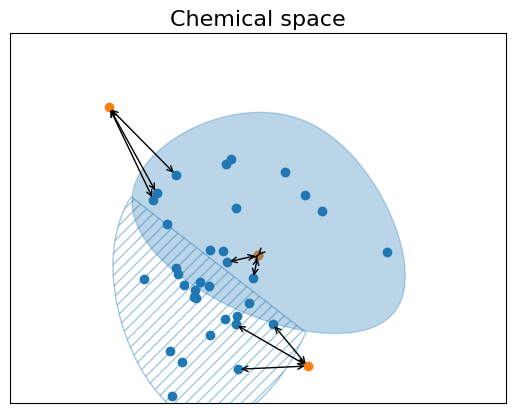

In [391]:
plt.scatter(train[:, 0], train[:, 1], marker='o') # , facecolor="none", edgecolors="tab:blue"
plt.scatter(additional_train[:, 0], additional_train[:, 1], color="tab:blue")
plt.scatter(test[:, 0], test[:, 1], marker='o') # , facecolor="none", edgecolors="tab:blue"

for point, neighbors in zip(test, nn_train, strict=True):
    for neighbor in neighbors:
        plt.annotate(text="", xy=point, xytext=neighbor, arrowprops=dict(arrowstyle="<->"))

plt.fill(x_smooth, y_smooth, color='tab:blue', alpha=0.3)
plt.fill(x_diff, y_diff, facecolor='none', edgecolor='tab:blue', alpha=0.4, hatch="///")

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.xticks([])
plt.yticks([])

plt.title("Chemical space", fontsize=16)
plt.show()